# The irreducible mass of black holes.

In [63]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats

In [64]:
sigma = 0.02
mu = 1
N = 100

chi = np.random.uniform(0,1,N)
M = np.random.normal(mu, sigma, N)

def M_irr(chi,M):
    return M*np.sqrt((1+np.sqrt(1-chi**2))/2)

Mirr = M_irr(chi,M)

(array([ 2.,  3.,  2.,  6.,  8., 13.,  8., 19., 21., 18.]),
 array([0.74927606, 0.77685495, 0.80443383, 0.83201272, 0.85959161,
        0.88717049, 0.91474938, 0.94232826, 0.96990715, 0.99748604,
        1.02506492]),
 <BarContainer object of 10 artists>)

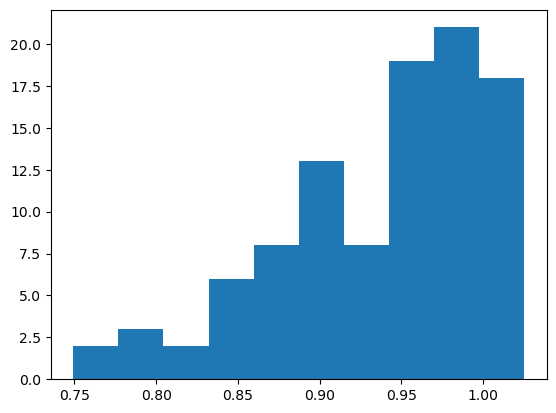

In [65]:
plt.hist(Mirr)

# Scott

0.01508104283022319


(array([ 1.,  1.,  0.,  4.,  0.,  3.,  3.,  6.,  3.,  7.,  6.,  4.,  5.,
        12.,  9., 14., 11.,  8.]),
 array([0.74927606, 0.7643571 , 0.77943815, 0.79451919, 0.80960023,
        0.82468128, 0.83976232, 0.85484336, 0.8699244 , 0.88500545,
        0.90008649, 0.91516753, 0.93024858, 0.94532962, 0.96041066,
        0.9754917 , 0.99057275, 1.00565379, 1.02073483]),
 <BarContainer object of 18 artists>)

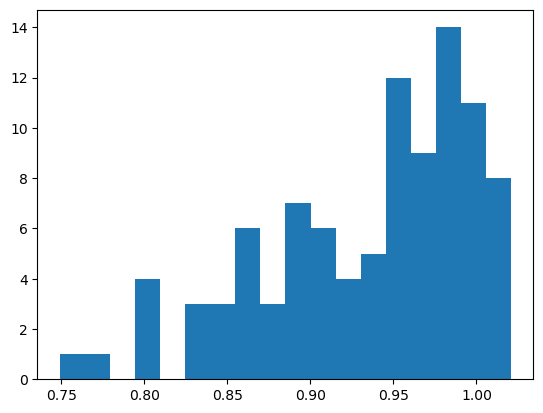

In [73]:
delta = 3.5*sigma/len(Mirr)**(1/3)

bins_scott = np.arange(np.min(Mirr), np.max(Mirr), delta)
print(delta)

plt.hist(Mirr, bins = bins_scott)

# Diaconis

0.038878764444243825


(array([ 2.,  4.,  9., 15., 12., 29., 26.]),
 array([0.74927606, 0.78815483, 0.82703359, 0.86591236, 0.90479112,
        0.94366988, 0.98254865, 1.02142741]),
 <BarContainer object of 7 artists>)

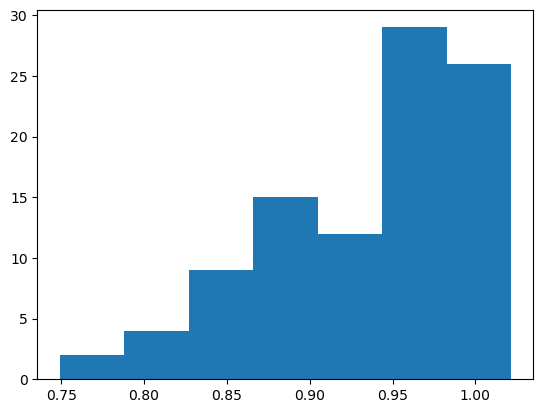

In [75]:
from astroML import stats as astroMLstats

sigmaG = astroMLstats.sigmaG(Mirr)
delta = 2.7*sigmaG/len(Mirr)**(1/3)
print(delta)

bins_diac = np.arange(np.min(Mirr), np.max(Mirr), delta)

plt.hist(Mirr, bins = bins_diac)

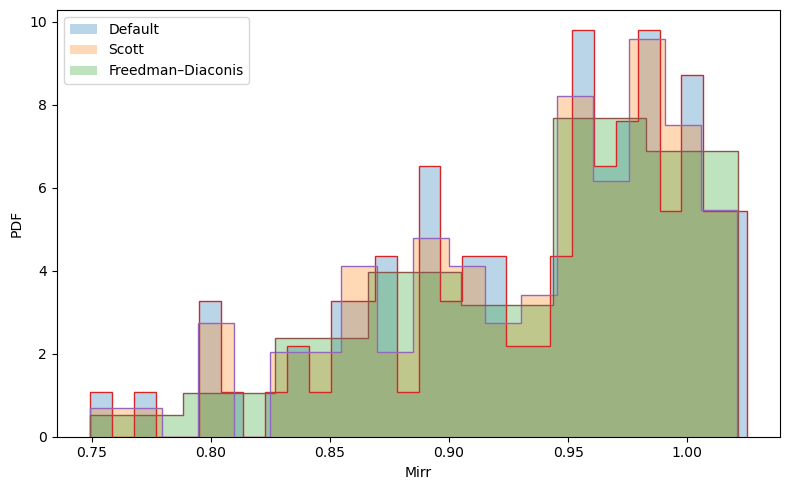

In [78]:
import matplotlib.pyplot as plt

data = Mirr

plt.figure(figsize=(8,5))

# istogrammi normalizzati (pdf)
plt.hist(data, bins=30, density=True, alpha=0.3, histtype='stepfilled', label='Default')
plt.hist(data, bins=bins_scott, density=True, alpha=0.3, histtype='stepfilled', label='Scott')
plt.hist(data, bins=bins_diac, density=True, alpha=0.3, histtype='stepfilled', label='Freedman–Diaconis')

# opzionale: contorni per maggiore leggibilità
plt.hist(data, bins=30, density=True, histtype='step')
plt.hist(data, bins=bins_scott, density=True, histtype='step')
plt.hist(data, bins=bins_diac, density=True, histtype='step')

plt.xlabel("Mirr")
plt.ylabel("PDF")
plt.legend()
plt.tight_layout()
plt.show()

# KDE

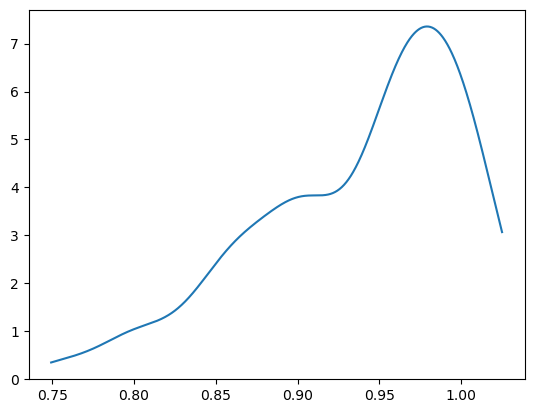

In [68]:
from sklearn.neighbors import KernelDensity

xgrid = np.linspace(Mirr.min(),Mirr.max(),1000)

def kde_sklearn(Mirr, bandwidth = 0.1, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(Mirr[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)


PDFtophat = kde_sklearn(Mirr,bandwidth=0.02, kernel="gaussian") 
plt.plot(xgrid,PDFtophat)

# KS distance

In [ ]:
distance = Mirr - 